In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
print("imports done")

imports done


In [2]:
df = pd.read_csv("../data/paysim.csv")
df = df[df["nameOrig"].str.startswith("C")].copy()

print(f"Transactions: {len(df):,}")

Transactions: 6,362,620


In [3]:
# for each account: what was their first transaction type, and what was their total volume?
first_tx_type = (
    df.sort_values("step")
    .groupby("nameOrig")
    .first()[["type"]]
    .rename(columns={"type": "first_tx_type"})
)

total_amount = (
    df.groupby("nameOrig")["amount"]
    .sum()
    .rename("total_amount")
)

account_df = first_tx_type.join(total_amount).reset_index()

print("Accounts per first-transaction type:")
print(account_df["first_tx_type"].value_counts())
account_df.head()

Accounts per first-transaction type:
first_tx_type
CASH_OUT    2234255
PAYMENT     2148335
CASH_IN     1397216
TRANSFER     532128
DEBIT         41373
Name: count, dtype: int64


,nameOrig,first_tx_type,total_amount
0,C1000000639,CASH_OUT,244486.46
1,C1000001337,PAYMENT,3170.28
2,C1000001725,PAYMENT,8424.74
3,C1000002591,CASH_IN,261877.19
4,C1000003372,CASH_IN,20528.65


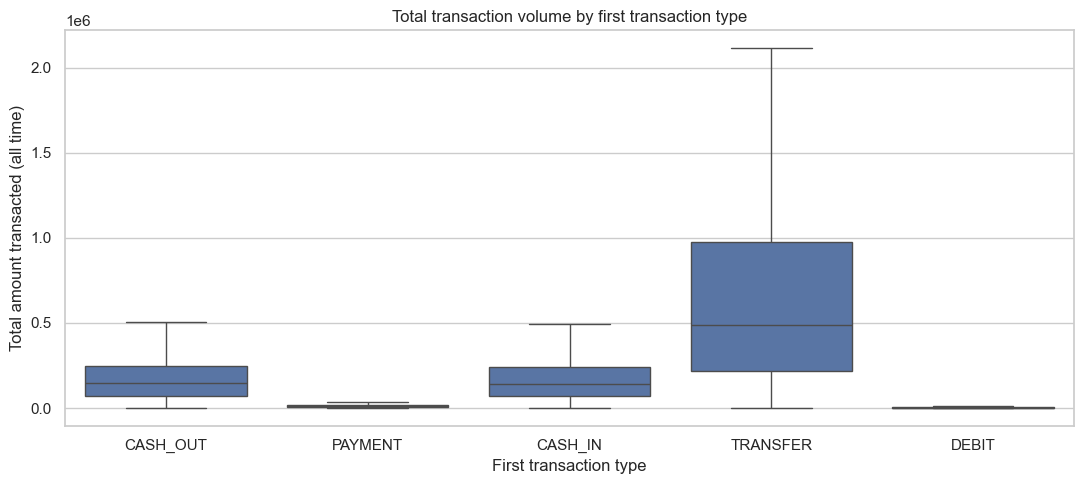

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=account_df,
    x="first_tx_type",
    y="total_amount",
    showfliers=False,
    ax=ax
)
ax.set_title("Total transaction volume by first transaction type")
ax.set_xlabel("First transaction type")
ax.set_ylabel("Total amount transacted (all time)")
plt.tight_layout()
plt.show()

In [5]:
group_a = account_df[account_df["first_tx_type"] == "CASH_OUT"]["total_amount"]
group_b = account_df[account_df["first_tx_type"] == "PAYMENT"]["total_amount"]

print(f"CASH_OUT-first accounts: {len(group_a):,}")
print(f"PAYMENT-first accounts:  {len(group_b):,}")
print(f"\nMean total amount (CASH_OUT-first): {group_a.mean():,.2f}")
print(f"Mean total amount (PAYMENT-first):  {group_b.mean():,.2f}")

# Welch's t-test (doesn't assume equal variance — safer than standard t-test)
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

# Cohen's d — effect size, tells you if the difference is PRACTICALLY meaningful
pooled_std = np.sqrt((group_a.std()**2 + group_b.std()**2) / 2)
cohens_d = (group_a.mean() - group_b.mean()) / pooled_std

print(f"\nT-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_value:.6f}")
print(f"Cohen's d:    {cohens_d:.4f}")
print(f"\nStatistically significant (p < 0.05)? {p_value < 0.05}")

CASH_OUT-first accounts: 2,234,255
PAYMENT-first accounts:  2,148,335

Mean total amount (CASH_OUT-first): 176,542.71
Mean total amount (PAYMENT-first):  13,343.78

T-statistic:  1357.2670
P-value:      0.000000
Cohen's d:    1.2851

Statistically significant (p < 0.05)? True


In [6]:
if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"

print(f"Effect size interpretation: {effect}")
print(f"""
---
INTERPRETATION:
- P-value {p_value:.6f} {'< 0.05 → the difference is statistically significant' if p_value < 0.05 else '> 0.05 → no statistical significance'}
- Cohen's d of {cohens_d:.3f} indicates a {effect} practical effect
- CASH_OUT-first users transact {((group_a.mean() / group_b.mean()) - 1) * 100:.1f}% {'more' if group_a.mean() > group_b.mean() else 'less'} in total volume than PAYMENT-first users
---
BUSINESS RECOMMENDATION:
If CASH_OUT-first users show higher lifetime volume, a mobile money operator 
like JazzCash/Easypaisa could design onboarding nudges that encourage a 
cash-out as the first action — this analysis provides the justification to 
run a real controlled experiment testing that hypothesis.
""")

Effect size interpretation: large

---
INTERPRETATION:
- P-value 0.000000 < 0.05 → the difference is statistically significant
- Cohen's d of 1.285 indicates a large practical effect
- CASH_OUT-first users transact 1223.0% more in total volume than PAYMENT-first users
---
BUSINESS RECOMMENDATION:
If CASH_OUT-first users show higher lifetime volume, a mobile money operator 
like JazzCash/Easypaisa could design onboarding nudges that encourage a 
cash-out as the first action — this analysis provides the justification to 
run a real controlled experiment testing that hypothesis.



C:\Users\Dell\AppData\Local\Temp\ipykernel_2844\3466844742.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


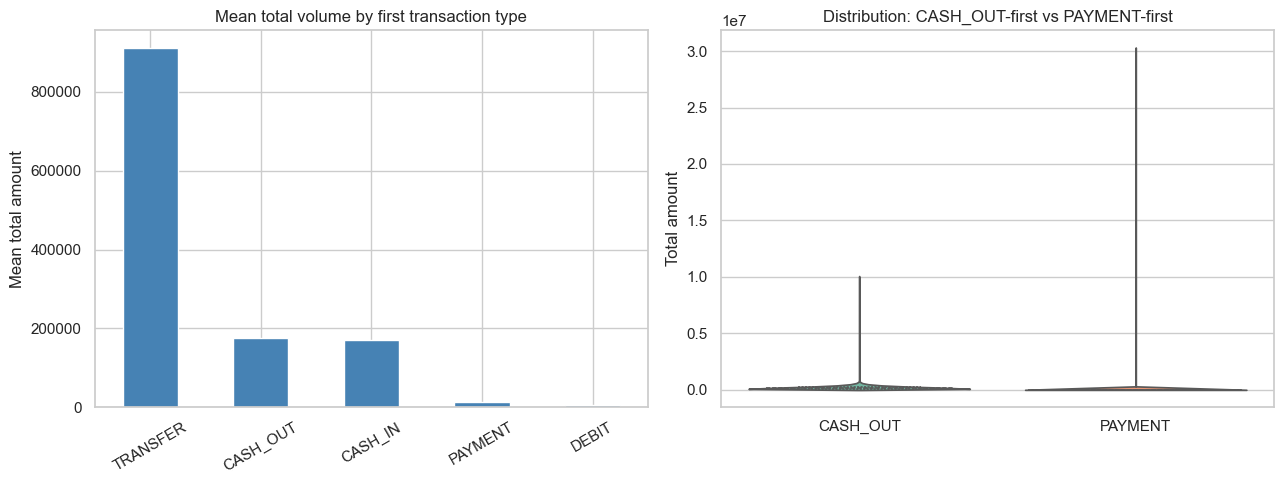

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# mean comparison bar chart
means = account_df.groupby("first_tx_type")["total_amount"].mean().sort_values(ascending=False)
means.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Mean total volume by first transaction type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean total amount")
axes[0].tick_params(axis="x", rotation=30)

# focused comparison of just CASH_OUT vs PAYMENT
subset = account_df[account_df["first_tx_type"].isin(["CASH_OUT", "PAYMENT"])]
sns.violinplot(
    data=subset,
    x="first_tx_type",
    y="total_amount",
    ax=axes[1],
    palette="Set2",
    inner="quartile"
)
axes[1].set_title("Distribution: CASH_OUT-first vs PAYMENT-first")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total amount")

plt.tight_layout()
plt.show()